In [1]:
from pyspark.sql.functions import col, when,col, lit, when
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import pandas as pd
import helper_functions as hf

##### Initialize Spark Session

In [2]:
spark = hf.initialize_spark()

#### Defining ETL Pipeline for TMDB_Movie_Data_Analysis with Pyspark

In [3]:
# Main processing function
def main(spark):

    # Step 1: Fetch Movie Data from API

    raw_movies_df = hf.process_movie_data(spark)
    
    # Process the data
    # First extract additional columns
    extracted_df = hf.get_movie_columns(raw_movies_df)


    # Step 2: Data Cleaning and Preprocessing
    # clean and transform
    extracted_df = hf.clean_movie_data(
        df=extracted_df,
        pipe_columns=['genres', 'spoken_languages', 'production_countries', 'production_companies'],
        collection_col='belongs_to_collection',
        columns_to_drop=['adult', 'imdb_id', 'original_title', 'video', 'homepage', 'reviews', 'credits', 'backdrop_path']
    )

    # Define column categories for final processing
    numeric_columns = ['budget', 'revenue', 'id', 'popularity', 'vote_average', 'vote_count', 'rating', 'crew_size', 'cast_size', 'runtime']
    money_columns = ['budget', 'revenue']
    placeholders = ['no data', 'none', 'n/a', '']
    
    # Handle incorrect data using your custom function
    processed_df = hf.handle_incorrect_data(extracted_df, 
                                        numeric_columns=numeric_columns,
                                        money_columns=money_columns,
                                        placeholders=placeholders)
    
  
    column_order = ['id', 'title', 'tagline', 'release_date', 'genres', 'belongs_to_collection',
               'original_language', 'budget_musd', 'revenue_musd', 'production_companies',
               'production_countries', 'vote_count', 'vote_average', 'popularity', 'runtime',
               'overview', 'spoken_languages', 'poster_path', 'cast', 'cast_size', 'directors', 'crew_size']

   
    print('Filter to include only Released movies, then drop status')
    if "status" in processed_df.columns:
        temp_df = processed_df.filter(col("status") == "Released").drop("status")

    temp_df.show(5, truncate=True)


    processed_df= hf.reorder_columns(processed_df, column_order)



    print("Sample of processed data:")
    processed_df.show(5, truncate=True)

    # Step 3: KPI Implementation & Analysis
    #caching dataframe for kpi implementation
    processed_df.cache()

    processed_df = processed_df.withColumn(
             "profit", col("revenue_musd") - col("budget_musd")
         ).withColumn(
            "roi", when(col("budget_musd") > 0, col("revenue_musd") / col("budget_musd")).otherwise(None)
        )


    processed_df.cache()

    all_sql_rankings = hf.get_movie_rankings(processed_df,spark)

    # top 5 highest rated movies with ≥10 votes
    all_sql_rankings["Highest Rated Movies (≥10 votes)"].show(5)


    processed_df.createOrReplaceTempView("movies")


    
    print("Advanced Query")
    spark.sql("""
            SELECT *
            FROM movies
            WHERE genres LIKE '%Science Fiction%'
            AND genres LIKE '%Action%'
            AND array_contains(cast, 'Bruce Willis')
            ORDER BY rating DESC
            """).show(truncate=False)
   
    spark.sql("""
            SELECT *
            FROM movies
            WHERE array_contains(cast, 'Uma Thurman')
            AND array_contains(directors, 'Quentin Tarantino')
            ORDER BY runtime ASC
        """).show(truncate=False)

    # Create a new column indicating whether the movie belongs to a franchise
    processed_df = processed_df.withColumn(
        "is_franchise", 
        when(col("belongs_to_collection").isNotNull(), lit(True)).otherwise(lit(False))
    )

    processed_df.cache()
    # Create a temporary view to use SQL for the franchise comparison
    processed_df.createOrReplaceTempView("movies")

    # Compare franchise vs standalone movies
    franchise_comparison = spark.sql("""
        SELECT 
            is_franchise,
            AVG(revenue_musd) AS mean_revenue,
            percentile_approx(roi, 0.5) AS median_roi,
            AVG(budget_musd) AS mean_budget,
            AVG(popularity) AS mean_popularity,
            AVG(vote_average) AS mean_rating
        FROM movies
        GROUP BY is_franchise
    """)

    print("Franchise vs. Standalone Movie Performance:")
    franchise_comparison.show()

     # Most Successful Franchises
     # All franchise metrics
    hf.franchise_stats(spark).show(truncate=False)

    hf.franchise_stats(spark, revenue=True).show()

    # Directors with total revenue and avg rating
    hf.director_stats(spark, revenue=True, rating=True).show()

    # Only director movie count (everything else False)
    hf.director_stats(spark, revenue=False, rating=False).show()



    # Add these to your rankings dictionary
    all_sql_rankings["Franchise vs Standalone"] = franchise_comparison
    all_sql_rankings["Most Successful Franchises_Overall"] =hf.franchise_stats
    all_sql_rankings["Most Successful Directors_Overall"] = hf.director_stats

    
    #Viusalization
    processed_df.cache()
     # Cache and convert processed_df to Pandas once
    visual_data = processed_df.cache().toPandas()

   # 1. Revenue vs. Budget
    visual_data.plot.scatter(x="budget_musd", y="revenue_musd", alpha=0.3, figsize=(10, 6), title="Revenue vs. Budget")
    plt.tight_layout()
    plt.show()

    # 2. ROI by Genre
    visual_data['genres'] = visual_data['genres'].str.split('|')
    visual_data.explode("genres").groupby("genres")["roi"].mean().sort_values().plot.barh(figsize=(12, 8), title="Average ROI by Genre")
    plt.tight_layout()
    plt.show()

    # 3. Popularity vs. Rating
    visual_data.plot.scatter(x="vote_average", y="popularity", alpha=0.3, figsize=(10, 6), title="Popularity vs. Rating")
    plt.tight_layout()
    plt.show()

    # Extract year from release_date and calculate the mean revenue per year
    visual_data['year'] = pd.to_datetime(visual_data['release_date']).dt.year
    visual_data.groupby("year")["revenue_musd"].mean().reset_index().sort_values("year").plot(
        x="year", y="revenue_musd", marker='o', figsize=(12, 6), title="Yearly Box Office Performance"
    )
    plt.tight_layout()
    plt.show()

    # 5. Franchise vs. Standalone Comparison
    franchise_comparison.toPandas().set_index("is_franchise").T.plot.bar(figsize=(12, 8), title="Franchise vs. Standalone Movies Performance")
    plt.tight_layout()
    plt.show()
    
        

#### CALL PIPELINE

INFO:root:Parquet file loaded successfully.
INFO:root:Starting to extract movie columns.


Loaded data from ./dataset/raw/raw_tmdb_movies.parquet


INFO:root:Movie columns extraction completed successfully.
INFO:root:Starting data cleaning process.
INFO:root:Data cleaning completed successfully.
INFO:root:Starting data correction process.
INFO:root:Processed movie data saved to tmdb_movies_processed.parquet


Filter to include only Released movies, then drop status


INFO:root:Starting to reorder columns.
INFO:root:Column reordering completed successfully.


...

+-----------------------------------+-----------+------------+----------+------------------+------------------+------------------+
|belongs_to_collection              |movie_count|total_budget|avg_budget|total_revenue     |avg_revenue       |avg_rating        |
+-----------------------------------+-----------+------------+----------+------------------+------------------+------------------+
|The Avengers Collection            |4          |1241.0      |310.25    |7776.073348       |1944.018337       |7.871000051498413 |
|Star Wars Collection               |2          |445.0       |222.5     |3400.9224540000005|1700.4612270000002|7.019500017166138 |
|Jurassic Park Collection           |2          |320.0       |160.0     |2982.00374        |1491.00187        |6.615499973297119 |
|Avatar Collection                  |1          |237.0       |237.0     |2923.706026       |2923.706026       |7.5879998207092285|
|Frozen Collection                  |2          |300.0       |150.0     |2727.90248

INFO:root:Running director stats...


+---------------------+-----------+------------------+------------------+
|belongs_to_collection|movie_count|     total_revenue|       avg_revenue|
+---------------------+-----------+------------------+------------------+
| The Avengers Coll...|          4|       7776.073348|       1944.018337|
| Star Wars Collection|          2|3400.9224540000005|1700.4612270000002|
| Jurassic Park Col...|          2|        2982.00374|        1491.00187|
|    Avatar Collection|          1|       2923.706026|       2923.706026|
|    Frozen Collection|          2|2727.9024849999996|1363.9512424999998|
| The Lion King (Re...|          1|       1662.020819|       1662.020819|
| The Fast and the ...|          1|            1515.4|            1515.4|
| Black Panther Col...|          1|       1349.926083|       1349.926083|
| Harry Potter Coll...|          1|       1341.511219|       1341.511219|
| The Incredibles C...|          1|       1242.805359|       1242.805359|
+---------------------+-----------+---

INFO:root:Running director stats...


+--------------------+-----------+-------------+-----------------+
|           directors|movie_count|total_revenue|       avg_rating|
+--------------------+-----------+-------------+-----------------+
|     [James Cameron]|          2|  5187.868379|7.746500015258789|
|[Joe Russo, Antho...|          2|  4851.854139|8.236000061035156|
|       [Joss Whedon]|          2|  2924.219209| 7.50600004196167|
|       [J.J. Abrams]|          1|  2068.223624|7.261000156402588|
|   [Colin Trevorrow]|          1|  1671.537444|6.692999839782715|
|       [Jon Favreau]|          1|  1662.020819|7.110000133514404|
|         [James Wan]|          1|       1515.4| 7.22599983215332|
|[Jennifer Lee, Ch...|          1|  1453.683476|7.249000072479248|
|      [Ryan Coogler]|          1|  1349.926083|7.373000144958496|
|       [David Yates]|          1|  1341.511219|8.086999893188477|
+--------------------+-----------+-------------+-----------------+

+--------------------+-----------+
|           directors|movi

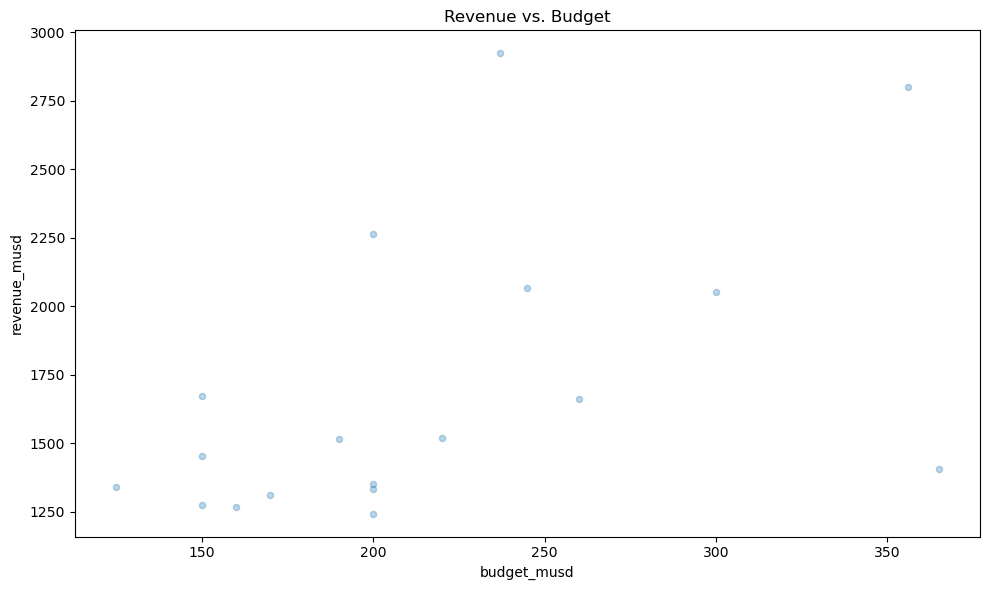

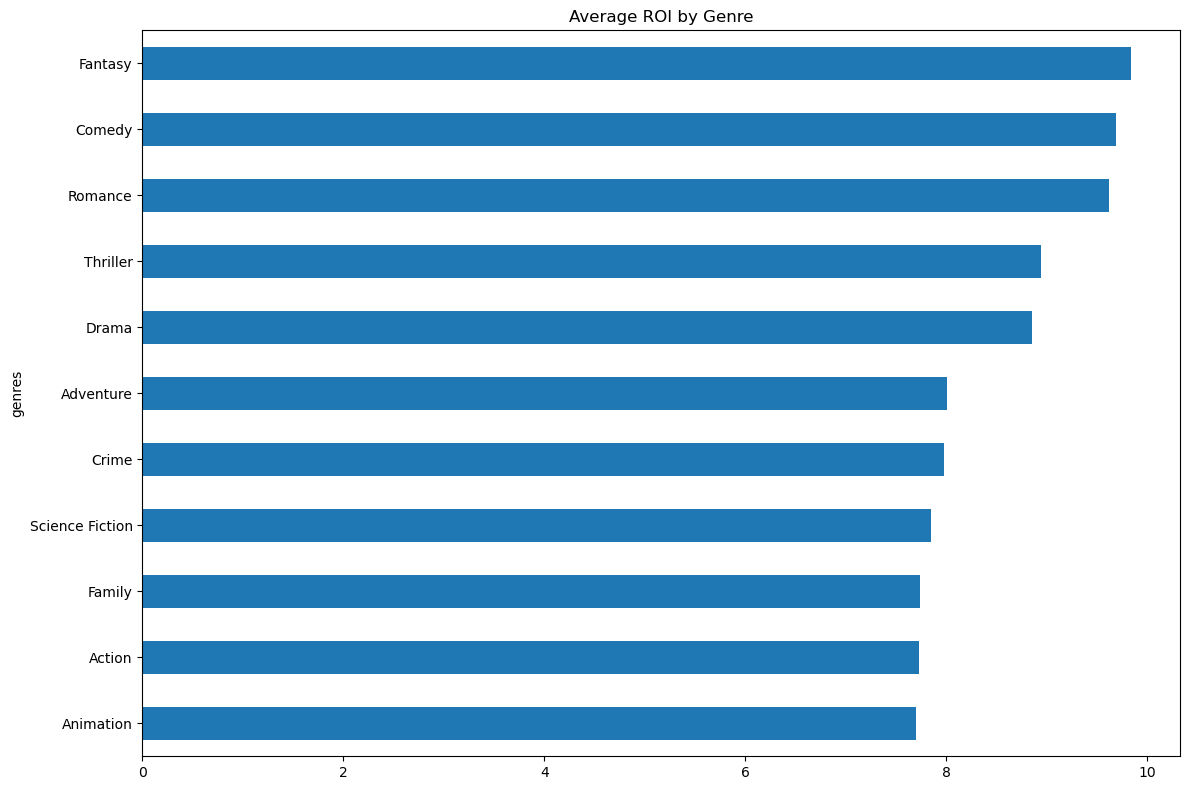

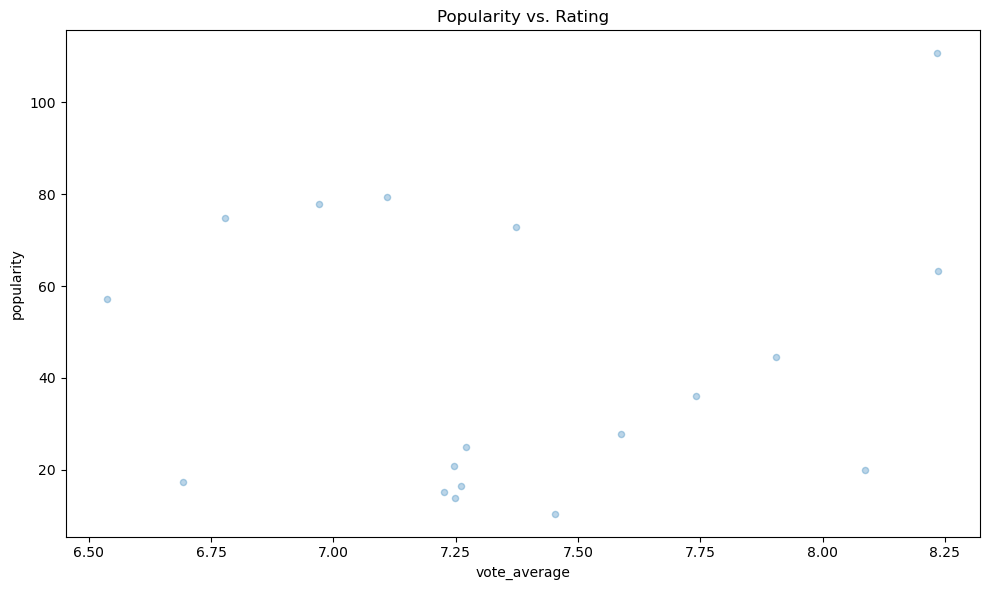

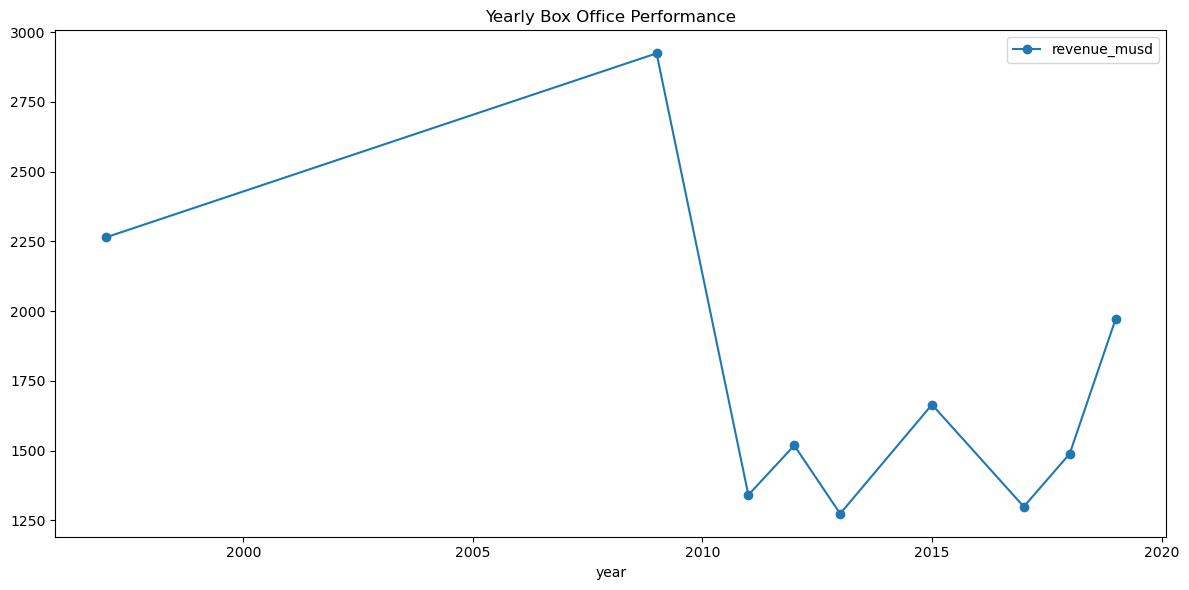

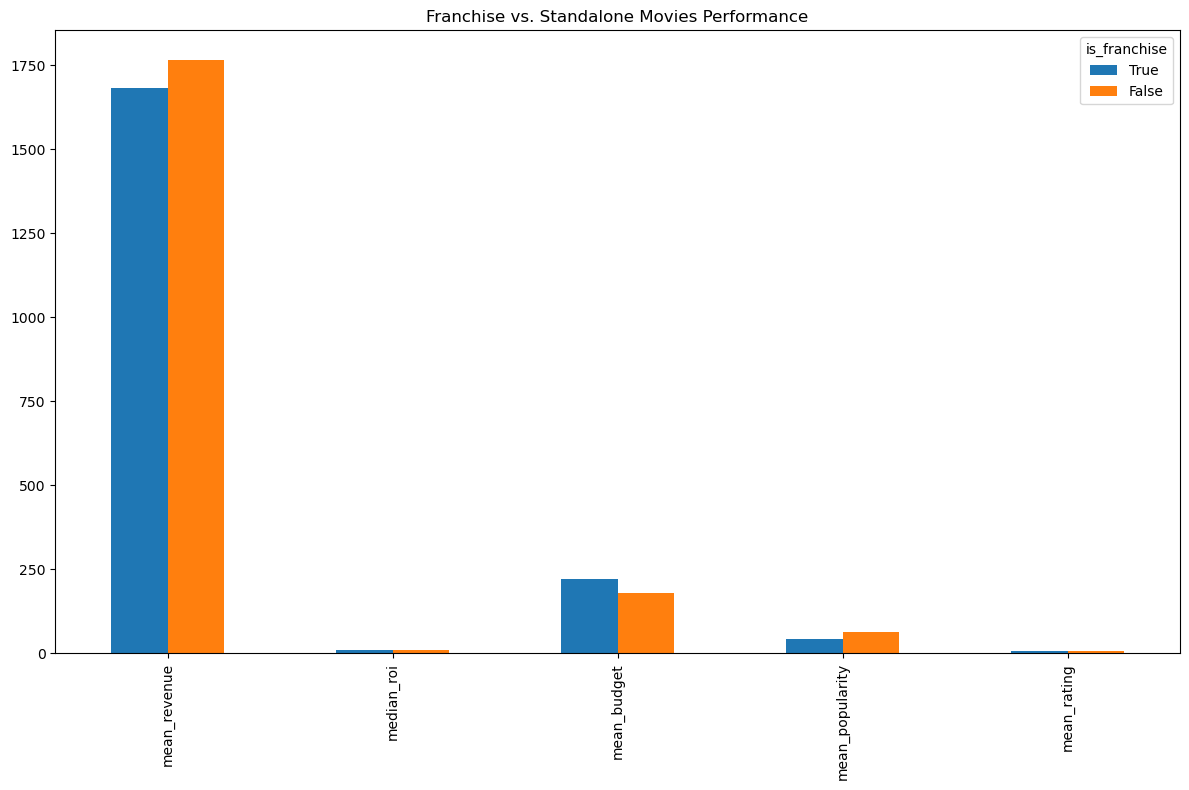

In [4]:
main(spark)

In [5]:
# Stop Spark session
spark.stop()